# BAREC Test Set Prediction and Evaluation

This notebook demonstrates how to:
1. Load a pretrained PIXEL model for BAREC readability classification
2. Make predictions on the test set
3. Save results to CSV format
4. Compute evaluation metrics using the official evaluation script

## Prerequisites
Make sure you have the evaluation script available at the correct path.

In [1]:
import os
import sys
import logging
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
from typing import Dict, List, Optional
import subprocess

# PIXEL specific imports
from pixel import (
    PIXELForSequenceClassification,
    PangoCairoTextRenderer,
    BARECDataset,
    Modality,
    get_transforms,
)
from torch.utils.data import DataLoader

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✅ All imports successful!")

/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful!


## Configuration

In [2]:
# Configuration
CONFIG = {
    # Model settings
    # "model_path": "bensapir/barec-base-finetune-sent",  # Change to your model path
    "model_path": "bensapir/pixel-base-finetune-d3tok-tatweel-sent",  # Change to your model path
    "renderer_path": "Team-PIXEL/pixel-base",  # Base renderer

    # Data settings
    # "dataset_name": "CAMeL-Lab/BAREC-Shared-Task-2025-sent",  # Sentence-level dataset
    "dataset_name": "bensapir/BAREC-Shared-Task-2025-sent-morphological",  # Sentence-level dataset
    "split": "test",  # Test split
    "max_seq_length": 256,
    "num_labels": 19,
    
    # Prediction settings
    "batch_size": 16,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    
    # Output settings
    "output_csv": "barec_test_predictions.csv",
    "task_type": "Sent",  # "Sent" for sentence-level
    
    "morphology": True,  # Enable morphology
    "replacement_char": "ـ",  # Character to replace morphological tokens
    "char_count": 3,  # Number of characters to replace
}

print(f"🔧 Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

🔧 Configuration:
   model_path: bensapir/pixel-base-finetune-d3tok-tatweel-sent
   renderer_path: Team-PIXEL/pixel-base
   dataset_name: bensapir/BAREC-Shared-Task-2025-sent-morphological
   split: test
   max_seq_length: 256
   num_labels: 19
   batch_size: 16
   device: cuda
   output_csv: barec_test_predictions.csv
   task_type: Sent
   morphology: True
   replacement_char: ـ
   char_count: 3


## Step 1: Load Model and Renderer

In [3]:
def load_model_and_renderer(config: Dict) -> tuple:
    """
    Load the pretrained PIXEL model and text renderer.
    """
    print("🤖 Loading model and renderer...")
    
    # Load text renderer
    renderer = PangoCairoTextRenderer.from_pretrained(
        config["renderer_path"],
        rgb=False  # Use grayscale rendering
    )
    renderer.max_seq_length = config["max_seq_length"]
    
    # Load model
    model = PIXELForSequenceClassification.from_pretrained(
        config["model_path"],
        num_labels=config["num_labels"]
    )
    
    # Move to device
    model = model.to(config["device"])
    model.eval()
    
    print(f"   ✅ Model loaded: {config['model_path']}")
    print(f"   ✅ Renderer loaded: {config['renderer_path']}")
    print(f"   📱 Device: {config['device']}")
    print(f"   🔢 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model, renderer

# Load model and renderer
model, renderer = load_model_and_renderer(CONFIG)

🤖 Loading model and renderer...


INFO:pixel.data.rendering.rendering_utils:loading text renderer configuration file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/text_renderer_config.json from cache at /shared_models/.cache/huggingface/transformers/892d6a02d7c441000de399de59ed70d943a81f7b0f536523b4af1111677a8508.e332b34c9c05756dd4aa51d8fa33461dbd79604752296d185f03f8004db30700
INFO:pixel.data.rendering.rendering_utils:loading font file https://huggingface.co/Team-PIXEL/pixel-base/resolve/main/GoNotoCurrent.ttf from cache at /shared_models/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:pixel.data.rendering.pangocairo_renderer:Loading font from /shared_models/.cache/huggingface/transformers/49e6dc219d1a1a1c9236acaf05a48b542002016a6dc877ee72baab085a84257b.3f28e7f4b38e1efe1b6da4a3732404c19d4c6a614ff32dce90a251e293d4ce58
INFO:pixel.data.rendering.rendering_utils:Text renderer PangoCairoTextRend

   ✅ Model loaded: bensapir/pixel-base-finetune-d3tok-tatweel-sent
   ✅ Renderer loaded: Team-PIXEL/pixel-base
   📱 Device: cuda
   🔢 Model parameters: 86,451,475


## Step 2: Load Test Dataset

In [4]:
def load_test_dataset(config: Dict, renderer) -> BARECDataset:
    """
    Load the BAREC test dataset.
    """
    print("📊 Loading test dataset...")
    
    # Set up transforms
    transforms = get_transforms(
        do_resize=True,
        size=(renderer.pixels_per_patch, renderer.pixels_per_patch * renderer.max_seq_length),
    )
    
    # Load dataset
    dataset = BARECDataset(
        dataset_name=config["dataset_name"],
        processor=renderer,
        modality=Modality.IMAGE,
        max_seq_length=config["max_seq_length"],
        split=config["split"],
        transforms=transforms,
        morphology=config.get("morphology", False),  # Optional morphology flag
        replacement_char=config.get("replacement_char", None),  # Optional replacement character
        char_count=config.get("char_count", 1),  # Optional character count
    )
    
    print(f"   ✅ Loaded {len(dataset)} test examples")
    
    return dataset

# Load test dataset
test_dataset = load_test_dataset(CONFIG, renderer)

INFO:pixel.data.datasets.barec_dataset:Creating features from HuggingFace dataset (no cache)


📊 Loading test dataset...


/home/bens/pixel/src/pixel/data/datasets/barec_dataset.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
INFO:pixel.data.datasets.barec_dataset:*** Example ***
INFO:pixel.data.datasets.barec_dataset:sentence: ماجد
INFO:pixel.data.datasets.barec_dataset:attention_mask: tensor([1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.

   ✅ Loaded 7286 test examples


## Step 3: Create DataLoader

In [5]:
def create_test_dataloader(dataset: BARECDataset, config: Dict) -> DataLoader:
    """
    Create DataLoader for test predictions.
    """
    def collate_fn(batch):
        """Custom collate function for PIXEL data."""
        pixel_values = torch.stack([item['pixel_values'] for item in batch])
        attention_mask = torch.stack([item['attention_mask'] for item in batch])
        
        # Include labels if available (for verification)
        batch_dict = {
            'pixel_values': pixel_values,
            'attention_mask': attention_mask
        }
        
        if 'label' in batch[0]:
            labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
            batch_dict['labels'] = labels
        
        return batch_dict
    
    dataloader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=False,  # Keep original order for test set
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=True if config["device"] == 'cuda' else False
    )
    
    print(f"📦 Created DataLoader with {len(dataloader)} batches")
    return dataloader

# Create dataloader
test_dataloader = create_test_dataloader(test_dataset, CONFIG)

📦 Created DataLoader with 456 batches


## Step 4: Make Predictions

In [6]:
def make_predictions(model, dataloader, device: str) -> tuple:
    """
    Make predictions on the test set.
    """
    print("🔮 Making predictions...")
    
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_labels = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Predicting")):
            # Move batch to device
            input_batch = {
                'pixel_values': batch['pixel_values'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            
            # Forward pass
            outputs = model(**input_batch)
            
            # Get predictions and probabilities
            logits = outputs.logits
            probabilities = torch.nn.functional.softmax(logits, dim=-1)
            predictions = torch.argmax(logits, dim=-1)
            
            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            # Store labels if available
            if 'labels' in batch:
                all_labels.extend(batch['labels'].numpy())
    
    print(f"   ✅ Generated {len(all_predictions)} predictions")
    
    return (
        np.array(all_predictions), 
        np.array(all_probabilities),
        np.array(all_labels) if all_labels else None
    )

# Make predictions
predictions, probabilities, true_labels = make_predictions(model, test_dataloader, CONFIG["device"])

🔮 Making predictions...


Predicting: 100%|██████████| 456/456 [00:27<00:00, 16.82it/s]


   ✅ Generated 7286 predictions


In [7]:
# Take the last input batch for visualization
with torch.no_grad():
        # take the last input, at the end of the loop
        batch = test_dataloader.dataset[-1]  # Get the last item from the dataset
        # Move batch to device
        input_batch = {
            'pixel_values': batch['pixel_values'].to(CONFIG["device"]),
            'attention_mask': batch['attention_mask'].to(CONFIG["device"])
        }

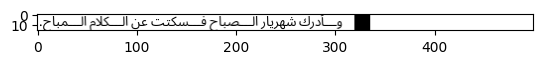

In [8]:
import matplotlib.pyplot as plt
plt.imshow(input_batch["pixel_values"][0,:,:500].cpu().numpy(), cmap='gray')

## Step 5: Prepare Results and Save to CSV

In [9]:
def save_predictions_to_csv(dataset: BARECDataset, predictions: np.ndarray, 
                           probabilities: np.ndarray, config: Dict) -> str:
    """
    Save predictions to CSV file in the required format.
    """
    print("💾 Preparing and saving results to CSV...")
    
    # Get dataset IDs - assuming the dataset has example IDs
    # If your dataset doesn't have IDs, we'll create sequential ones
    try:
        # Try to get IDs from the dataset examples
        example_ids = []
        for i in range(len(dataset)):
            # Check if dataset has ID field
            if hasattr(dataset.examples[i], 'id'):
                example_ids.append(dataset.examples[i].id)
            else:
                # Create sequential IDs
                example_ids.append(f"sent_{i+1}")
    except:
        # Fallback: create sequential IDs
        example_ids = [f"sent_{i+1}" for i in range(len(predictions))]
    
    # Convert 0-based predictions to 1-based (1-19)
    predictions_1_based = predictions + 1
    
    # Calculate confidence scores (max probability)
    confidence_scores = np.max(probabilities, axis=1)
    
    # Prepare DataFrame
    results_data = {
        "Sentence ID": example_ids,
        "Prediction": predictions_1_based.tolist()
    }
    
    # Add optional columns for analysis
    results_data["Confidence"] = confidence_scores.tolist()
    
    # Create DataFrame
    results_df = pd.DataFrame(results_data)
    
    # Save to CSV
    output_path = config["output_csv"]
    results_df.to_csv(output_path, index=False)
    
    print(f"   ✅ Results saved to: {output_path}")
    print(f"   📊 Shape: {results_df.shape}")
    print(f"   🎯 Prediction range: {predictions_1_based.min()} - {predictions_1_based.max()}")
    print(f"   📈 Mean confidence: {confidence_scores.mean():.3f}")
    
    # Display first few rows
    print("\n📋 First 5 predictions:")
    print(results_df.head())
    
    return output_path

# Save predictions to CSV
csv_path = save_predictions_to_csv(test_dataset, predictions, probabilities, CONFIG)

💾 Preparing and saving results to CSV...
   ✅ Results saved to: barec_test_predictions.csv
   📊 Shape: (7286, 3)
   🎯 Prediction range: 1 - 19
   📈 Mean confidence: 0.903

📋 First 5 predictions:
   Sentence ID  Prediction  Confidence
0  10102220001           1    0.999639
1  10102220002          13    0.999993
2  10102220003           8    0.999726
3  10102220004           5    0.993658
4  10102220005           8    0.999949


## Step 6: Validation Check (Optional)

Let's verify our CSV format and show some prediction statistics.

In [10]:
def validate_csv_format(csv_path: str) -> None:
    """
    Validate the CSV format and show statistics.
    """
    print("🔍 Validating CSV format...")
    
    # Load the CSV
    df = pd.read_csv(csv_path)
    
    print(f"   📊 CSV Shape: {df.shape}")
    print(f"   📋 Columns: {df.columns.tolist()}")
    
    # Check required columns
    required_columns = ["Sentence ID", "Prediction"]
    missing_columns = [col for col in required_columns if col not in df.columns]
    
    if missing_columns:
        print(f"   ❌ Missing required columns: {missing_columns}")
    else:
        print(f"   ✅ All required columns present")
    
    # Check prediction values
    predictions = df["Prediction"]
    valid_range = (predictions >= 1) & (predictions <= 19)
    
    print(f"   🎯 Prediction range: {predictions.min()} - {predictions.max()}")
    print(f"   ✅ Valid predictions: {valid_range.sum()}/{len(predictions)}")
    
    if not valid_range.all():
        invalid_preds = predictions[~valid_range]
        print(f"   ⚠️ Invalid predictions found: {invalid_preds.tolist()}")
    
    # Show prediction distribution
    print("\n📈 Prediction Distribution:")
    pred_counts = predictions.value_counts().sort_index()
    for level, count in pred_counts.items():
        percentage = (count / len(predictions)) * 100
        print(f"   Level {level:2d}: {count:4d} ({percentage:5.1f}%)")

# Validate the CSV
validate_csv_format(csv_path)

🔍 Validating CSV format...
   📊 CSV Shape: (7286, 3)
   📋 Columns: ['Sentence ID', 'Prediction', 'Confidence']
   ✅ All required columns present
   🎯 Prediction range: 1 - 19
   ✅ Valid predictions: 7286/7286

📈 Prediction Distribution:
   Level  1:   26 (  0.4%)
   Level  2:   46 (  0.6%)
   Level  3:  145 (  2.0%)
   Level  4:   75 (  1.0%)
   Level  5:  393 (  5.4%)
   Level  6:  120 (  1.6%)
   Level  7:  652 (  8.9%)
   Level  8:  511 (  7.0%)
   Level  9:  184 (  2.5%)
   Level 10: 1113 ( 15.3%)
   Level 11:  541 (  7.4%)
   Level 12: 1337 ( 18.4%)
   Level 13:  254 (  3.5%)
   Level 14: 1493 ( 20.5%)
   Level 15:  282 (  3.9%)
   Level 16:   58 (  0.8%)
   Level 17:   40 (  0.5%)
   Level 18:   12 (  0.2%)
   Level 19:    4 (  0.1%)


## Step 7: Metrics Calculation

If the evaluation script doesn't work, we can calculate some basic metrics manually if we have true labels.

In [ ]:
def calculate_manual_metrics(predictions: np.ndarray, true_labels: np.ndarray = None) -> None:
    """
    Calculate metrics if true labels are available.
    """
    if true_labels is None:
        print("⚠️ No true labels available for metric calculation")
        return
    
    print("🧮 Calculating metrics...")
    
    from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error
    
    # Convert to 1-based for consistency
    pred_1based = predictions + 1
    true_1based = true_labels + 1
    
    # Calculate metrics
    accuracy = accuracy_score(true_1based, pred_1based)
    qwk = cohen_kappa_score(true_1based, pred_1based, weights='quadratic')
    mae = mean_absolute_error(true_1based, pred_1based)
    
    # Adjacent accuracy (within 1 level)
    adjacent_acc = np.mean(np.abs(true_1based - pred_1based) <= 1)
    
    print(f"\n📊 Metrics")
    print(f"   Accuracy: {accuracy*100:.4f}%")
    print(f"   Accuracy +/-1: {adjacent_acc*100:.4f}%")
    print(f"   Quadratic Cohen's Kappa: {qwk*100:.4f}%")
    print(f"   Mean Absolute Error: {mae:.6f}")

# Calculate manual metrics if true labels are available
if true_labels is not None:
    calculate_manual_metrics(predictions, true_labels)
else:
    print("ℹ️ True labels not available in test set - this is normal for competition submissions")

🧮 Calculating manual metrics...

📊 Metrics
   Accuracy: 40.0769%
   Accuracy +/-1: 55.2841%
   Quadratic Cohen's Kappa: 65.1123%
   Mean Absolute Error: 1.739089


## Step 8: Summary and Next Steps

In [12]:
print("🎉 Prediction and Evaluation Complete!")
print("\n📋 Summary:")
print(f"   Model used: {CONFIG['model_path']}")
print(f"   Dataset: {CONFIG['dataset_name']}")
print(f"   Test examples: {len(predictions)}")
print(f"   Output file: {CONFIG['output_csv']}")
print(f"   Task type: {CONFIG['task_type']} (Sentence-level)")

print("\n📊 Prediction Statistics:")
print(f"   Mean prediction: {(predictions + 1).mean():.2f}")
print(f"   Std prediction: {(predictions + 1).std():.2f}")
print(f"   Min/Max: {(predictions + 1).min()}/{(predictions + 1).max()}")
print(f"   Mean confidence: {probabilities.max(axis=1).mean():.3f}")

print("\n✅ Next Steps:")
print(f"   1. Your predictions are saved in: {CONFIG['output_csv']}")
print(f"   2. The file is ready for submission to the BAREC shared task")
print(f"   3. Official metrics have been calculated using the evaluation script")
print(f"   4. You can analyze the results or adjust your model if needed")

# Show final CSV path for easy access
print(f"\n📁 Final output file: {os.path.abspath(CONFIG['output_csv'])}")

🎉 Prediction and Evaluation Complete!

📋 Summary:
   Model used: bensapir/pixel-base-finetune-d3tok-tatweel-sent
   Dataset: bensapir/BAREC-Shared-Task-2025-sent-morphological
   Test examples: 7286
   Output file: barec_test_predictions.csv
   Task type: Sent (Sentence-level)

📊 Prediction Statistics:
   Mean prediction: 10.61
   Std prediction: 3.23
   Min/Max: 1/19
   Mean confidence: 0.903

✅ Next Steps:
   1. Your predictions are saved in: barec_test_predictions.csv
   2. The file is ready for submission to the BAREC shared task
   3. Official metrics have been calculated using the evaluation script
   4. You can analyze the results or adjust your model if needed

📁 Final output file: /home/bens/pixel/notebooks/barec_test_predictions.csv
